In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load the separate files
df_feat = pd.read_csv('D:/download/archive/smartphone_battery_features.csv')
df_targ = pd.read_csv('D:/download/archive/smartphone_battery_targets.csv')

# Merge them horizontally (axis=1)
df = pd.concat([df_feat, df_targ], axis=1)

# Display columns to confirm everything is there
print(df.columns)
df.head()

Index(['Device_ID', 'device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index', 'Device_ID', 'current_battery_health_percent',
       'recommended_action'],
      dtype='object')


,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,Device_ID,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,207dd94c-0430-43aa-b388-4893447e628e,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,3f4d1d33-ba89-4814-a168-7b4cc75be26b,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,b4adca05-564f-4b70-ab69-e8d66e656463,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,4147e039-31b7-480a-bbc9-03cd0f66e9f1,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,67.2,Replace Battery


In [17]:

# Create the binary target variable
# 1 = Needs Replacement (Health < 80%), 0 = Healthy (Health >= 80%)
df['Needs_Replacement'] = (df['current_battery_health_percent'] < 80.0).astype(float)

print("Target Distribution:\n", df['Needs_Replacement'].value_counts())

Target Distribution:
 Needs_Replacement
1.0    4061
0.0     939
Name: count, dtype: int64


In [22]:
# Define Features (X) and Target (y)
X = df[['avg_battery_temp_celsius', 'device_age_months', 'avg_charging_cycles_per_week', 'usage_intensity_score']]
y = df['Needs_Replacement']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4000, 4)
Test size: (1000, 4)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Initialize and train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

Model Accuracy: 94.20%


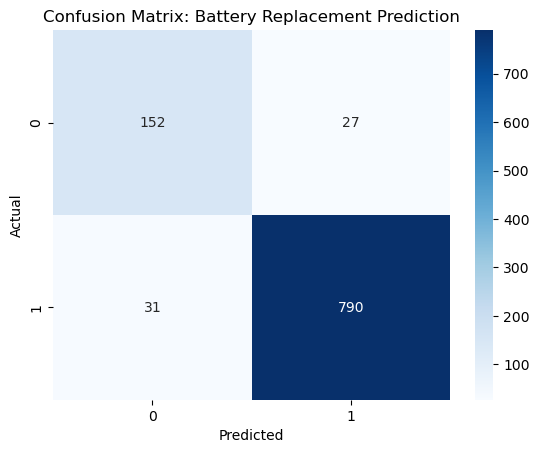

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.85      0.84       179
         1.0       0.97      0.96      0.96       821

    accuracy                           0.94      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.94      0.94      0.94      1000



In [21]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Battery Replacement Prediction')
plt.show()

# Detailed Classification Report (Precision, Recall, F1)
print("Classification Report:\n", classification_report(y_test, y_pred))